# Step 5. 리스크 분석 (VaR/CVaR + 스트레스 테스트)

---

### 개요

Step 4의 백테스트 결과를 바탕으로, 포트폴리오의 **리스크를 다각적으로 측정**합니다.

| 분석 항목 | 설명 |
|:---|:---|
| **VaR / CVaR** | 신뢰수준별 최대 손실과 꼬리 리스크 측정 |
| **리스크 기여도** | 각 자산이 포트폴리오 위험에 기여하는 비율 |
| **스트레스 테스트** | 역사적 위기 + 가상 시나리오 충격 분석 |
| **민감도 분석** | 롤링 변동성으로 시간 경과에 따른 리스크 변화 추적 |

4개 프로필(보수형/중립형/적극형/공격형) × MV 전략 기준으로 분석합니다.

In [1]:
# ============================================================
# 라이브러리 임포트 + 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from scipy.stats import norm

warnings.filterwarnings('ignore')

# 한글 시각화 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 경로 설정
V3_DIR   = os.getcwd()
DATA_DIR = os.path.join(V3_DIR, 'data')
IMG_DIR  = os.path.join(V3_DIR, 'images')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# --- 데이터 로드 ---
# 1) 포트폴리오 가격 (30개 자산)
df_prices = pd.read_csv(os.path.join(DATA_DIR, 'portfolio_prices.csv'),
                         index_col='Date', parse_dates=True)

# 2) 최적 가중치 (Step 3, full-sample 참고용)
df_weights = pd.read_csv(os.path.join(DATA_DIR, 'optimal_weights.csv'))

# 3) 프로필 정보
df_profiles = pd.read_csv(os.path.join(DATA_DIR, 'profiles.csv'))

# 4) 백테스트 결과 (Step 4 산출물)
# ⚠️ 주의 (2026-04-19 업데이트): Step 4 Option Y 적용 이후
#     backtest_results.csv는 '단순 수익률'로 저장됨 (로그 아님)
#     이 Step 5의 모든 후속 계산 (누적·drawdown·스트레스)은 단순 수익률 전제
bt_path = os.path.join(DATA_DIR, 'backtest_results.csv')
if os.path.exists(bt_path):
    df_bt = pd.read_csv(bt_path, index_col='Date', parse_dates=True)
    print(f'[OK] backtest_results.csv 로드: {df_bt.shape} (단순 수익률 기준)')
else:
    # Fallback: simple returns로 직접 계산 (Step 4 Option Y와 일관)
    print('[INFO] backtest_results.csv 없음 - 단순 수익률로 직접 계산')
    simple_returns = df_prices.pct_change().dropna()
    simple_returns = simple_returns.loc['2016-01-01':]  # ANALYSIS_START
    PROFILE_NAMES = ['보수형', '중립형', '적극형', '공격형']
    bt_dict = {}
    for pname in PROFILE_NAMES:
        w_sub = df_weights[(df_weights['profile'] == pname) &
                           (df_weights['strategy'] == 'MV')].set_index('ticker')['weight']
        w_aligned = w_sub.reindex(simple_returns.columns).fillna(0).values
        bt_dict[pname] = simple_returns.values @ w_aligned
    df_bt = pd.DataFrame(bt_dict, index=simple_returns.index)

# --- 로그·단순 수익률 이원 계산 (용도별 분리, 2026-04-19 업데이트) ---
# 로그 수익률: 공분산 추정 (Cell #6 리스크 기여도용)
log_returns = np.log(df_prices / df_prices.shift(1)).dropna()
log_returns = log_returns.loc['2016-01-01':]  # ANALYSIS_START

# 단순 수익률: df_bt와 일관 (스트레스 테스트 백업용)
simple_returns = df_prices.pct_change().dropna()
simple_returns = simple_returns.loc['2016-01-01':]  # ANALYSIS_START

# 프로필 이름 목록
PROFILE_NAMES = ['보수형', '중립형', '적극형', '공격형']
PROFILE_COLORS = {'보수형': '#2196F3', '중립형': '#4CAF50',
                  '적극형': '#FF9800', '공격형': '#F44336'}

print(f'\n포트폴리오 가격: {df_prices.shape}')
print(f'기간: {df_prices.index[0].date()} ~ {df_prices.index[-1].date()}')
print(f'백테스트 수익률: {df_bt.shape} (단순 수익률)')
print(f'로그 수익률: {log_returns.shape} (공분산용)')
print(f'프로필: {PROFILE_NAMES}')


[OK] backtest_results.csv 로드: (1948, 7) (단순 수익률 기준)

포트폴리오 가격: (3017, 30)
기간: 2014-01-02 ~ 2025-12-30
백테스트 수익률: (1948, 7) (단순 수익률)
로그 수익률: (2513, 30) (공분산용)
프로필: ['보수형', '중립형', '적극형', '공격형']


---

## 5-1. VaR / CVaR (Value-at-Risk / Conditional VaR)

### 핵심 개념

| 지표 | 질문 | 정의 |
|:---|:---|:---|
| **VaR** | "내일 최악의 경우 얼마나 잃을 수 있는가?" | 특정 신뢰수준(95%, 99%)에서의 **최대 예상 손실** |
| **CVaR** | "최악을 넘어서면 평균적으로 얼마나 잃는가?" | VaR를 초과하는 손실들의 **평균** (= Expected Shortfall) |

### 측정 방법

1. **Historical VaR/CVaR**: 실제 수익률 분포에서 백분위수로 직접 계산
   - 장점: 분포 가정 없음, 팅테일(fat tail) 반영
   - 단점: 과거 데이터에 의존

2. **Parametric VaR/CVaR**: 정규분포 가정 하에 해석적으로 계산
   - VaR = -(mu + z_alpha * sigma)
   - CVaR = -(mu - sigma * phi(z_alpha) / alpha)
   - 장점: 계산 간단, 신뢰구간 제공
   - 단점: 정규분포 가정이 실제와 괴리될 수 있음

In [2]:
# ============================================================
# VaR / CVaR 계산 함수 정의
# ============================================================

def historical_var_cvar(returns, confidence=0.95):
    """
    역사적 시뮬레이션 방법으로 VaR/CVaR 계산.
    실제 수익률 분포의 백분위수를 직접 사용.
    """
    r = returns.values.flatten()
    alpha = 1 - confidence
    # VaR: alpha 백분위수의 음수값 (손실을 양수로 표현)
    var = -np.percentile(r, alpha * 100)
    # CVaR: VaR 초과 손실의 평균
    cvar = -r[r <= -var].mean() if np.any(r <= -var) else var
    return {'VaR': var, 'CVaR': cvar}


def parametric_var_cvar(returns, confidence=0.95):
    """
    정규분포 가정 하에 해석적으로 VaR/CVaR 계산.
    mu, sigma를 추정하고 z-score로 변환.
    """
    mu = returns.mean()
    sigma = returns.std()
    alpha = 1 - confidence
    z = norm.ppf(alpha)           # 예: alpha=0.05 -> z ≈ -1.645
    var = -(mu + z * sigma)       # 손실을 양수로 표현
    cvar = -(mu - sigma * norm.pdf(z) / alpha)
    return {'VaR': var, 'CVaR': cvar}


# --- 4개 프로필 × 2개 방법 × 2개 신뢰수준으로 계산 ---
confidence_levels = [0.95, 0.99]
methods = {'Historical': historical_var_cvar, 'Parametric': parametric_var_cvar}

var_results = []
for pname in PROFILE_NAMES:
    ret = df_bt[pname]
    for conf in confidence_levels:
        for method_name, method_func in methods.items():
            result = method_func(ret, confidence=conf)
            var_results.append({
                '프로필': pname,
                '신뢰수준': f'{conf:.0%}',
                '방법': method_name,
                'VaR (%)': f"{result['VaR'] * 100:.3f}",
                'CVaR (%)': f"{result['CVaR'] * 100:.3f}",
            })

df_var_summary = pd.DataFrame(var_results)

# 피벗 테이블로 가독성 향상
print('=' * 70)
print('VaR / CVaR 요약 (1일 기준, 손실을 양수로 표시)')
print('=' * 70)
print(df_var_summary.to_string(index=False))
print('\n* VaR: 신뢰수준 내에서의 최대 예상 손실')
print('* CVaR: VaR를 초과하는 극단적 손실 시나리오의 평균 손실')

VaR / CVaR 요약 (1일 기준, 손실을 양수로 표시)
프로필 신뢰수준         방법 VaR (%) CVaR (%)
보수형  95% Historical   1.320    2.014
보수형  95% Parametric   1.342    1.694
보수형  99% Historical   2.382    3.125
보수형  99% Parametric   1.916    2.202
중립형  95% Historical   2.041    2.963
중립형  95% Parametric   2.007    2.533
중립형  99% Historical   3.553    4.569
중립형  99% Parametric   2.864    3.290
적극형  95% Historical   2.489    3.606
적극형  95% Parametric   2.466    3.113
적극형  99% Historical   4.299    5.638
적극형  99% Parametric   3.521    4.046
공격형  95% Historical   2.715    3.988
공격형  95% Parametric   2.742    3.462
공격형  99% Historical   4.527    6.215
공격형  99% Parametric   3.916    4.501

* VaR: 신뢰수준 내에서의 최대 예상 손실
* CVaR: VaR를 초과하는 극단적 손실 시나리오의 평균 손실


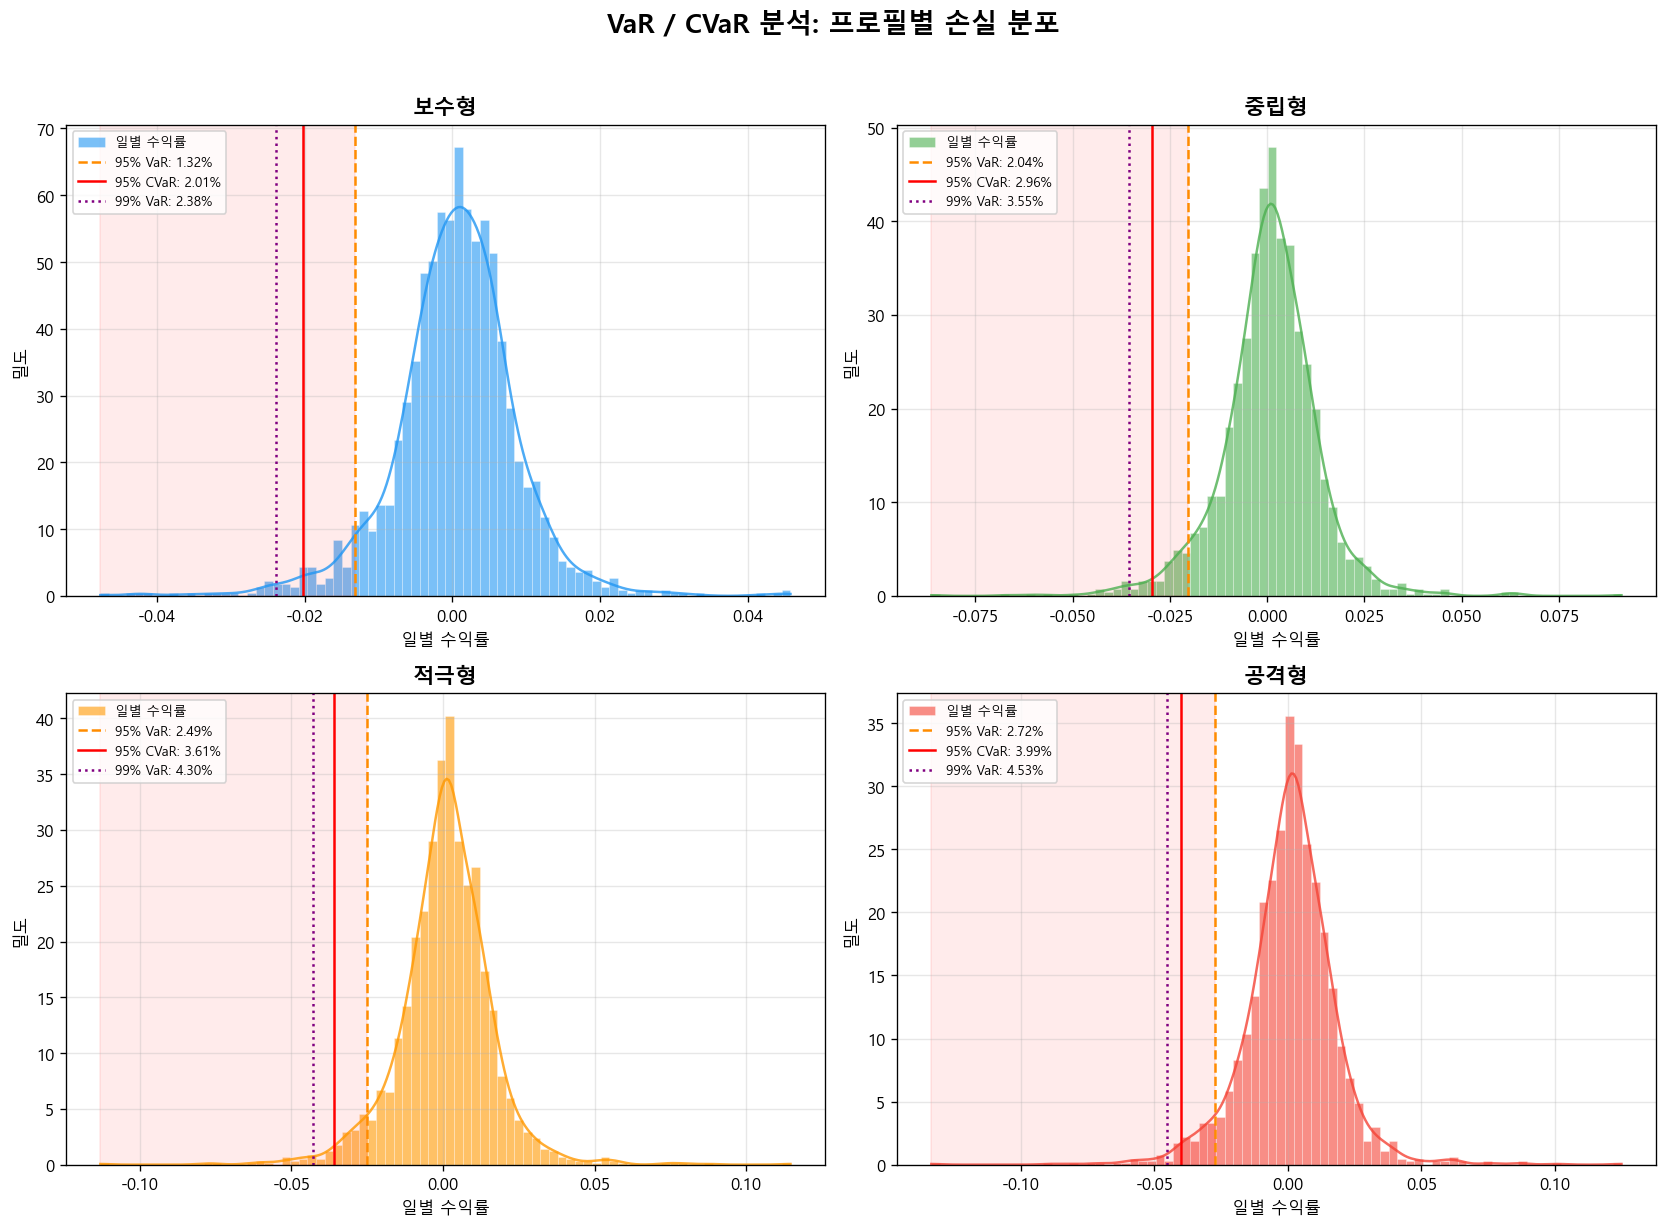

[SAVE] images/step5_01_var_cvar.png


In [3]:
# ============================================================
# 시각화: 손실 분포 + VaR/CVaR 라인 (2×2 subplot)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VaR / CVaR 분석: 프로필별 손실 분포', fontsize=16, fontweight='bold', y=1.02)

for idx, pname in enumerate(PROFILE_NAMES):
    ax = axes[idx // 2, idx % 2]
    ret = df_bt[pname].dropna()
    color = PROFILE_COLORS[pname]

    # 수익률 히스토그램
    ax.hist(ret, bins=80, density=True, alpha=0.6, color=color,
            edgecolor='white', linewidth=0.3, label='일별 수익률')

    # KDE 곡선 추가
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(ret)
    x_range = np.linspace(ret.min(), ret.max(), 300)
    ax.plot(x_range, kde(x_range), color=color, linewidth=1.5, alpha=0.8)

    # 95% VaR/CVaR 라인 (Historical)
    res_95 = historical_var_cvar(ret, confidence=0.95)
    res_99 = historical_var_cvar(ret, confidence=0.99)

    ax.axvline(-res_95['VaR'], color='darkorange', linestyle='--', linewidth=1.5,
               label=f'95% VaR: {res_95["VaR"]*100:.2f}%')
    ax.axvline(-res_95['CVaR'], color='red', linestyle='-', linewidth=1.5,
               label=f'95% CVaR: {res_95["CVaR"]*100:.2f}%')
    ax.axvline(-res_99['VaR'], color='purple', linestyle=':', linewidth=1.5,
               label=f'99% VaR: {res_99["VaR"]*100:.2f}%')

    # 손실 영역 음영 처리
    ax.axvspan(ret.min(), -res_95['VaR'], alpha=0.08, color='red')

    ax.set_title(f'{pname}', fontsize=13, fontweight='bold')
    ax.set_xlabel('일별 수익률')
    ax.set_ylabel('밀도')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'step5_01_var_cvar.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('[SAVE] images/step5_01_var_cvar.png')

---

## 5-2. 리스크 기여도 분석

### 개념

포트폴리오의 총 리스크에 각 자산이 얼마나 기여하는지를 분해합니다.

### 수식

$$RC_i = w_i \times \frac{(\Sigma \mathbf{w})_i}{\sigma_p}$$

- $w_i$: 자산 $i$의 가중치
- $\Sigma$: 공분산 행렬
- $\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$: 포트폴리오 변동성
- $\sum_i RC_i = \sigma_p$ (리스크 기여도의 합 = 총 리스크)

### 해석 가이드

- 특정 자산의 리스크 기여도가 높다면 → 해당 자산이 포트폴리오 위험의 주요 원인
- 리스크 패리티 포트폴리오: 모든 자산의 리스크 기여도가 동일
- MV 포트폴리오: 소수 자산에 리스크가 집중될 수 있음

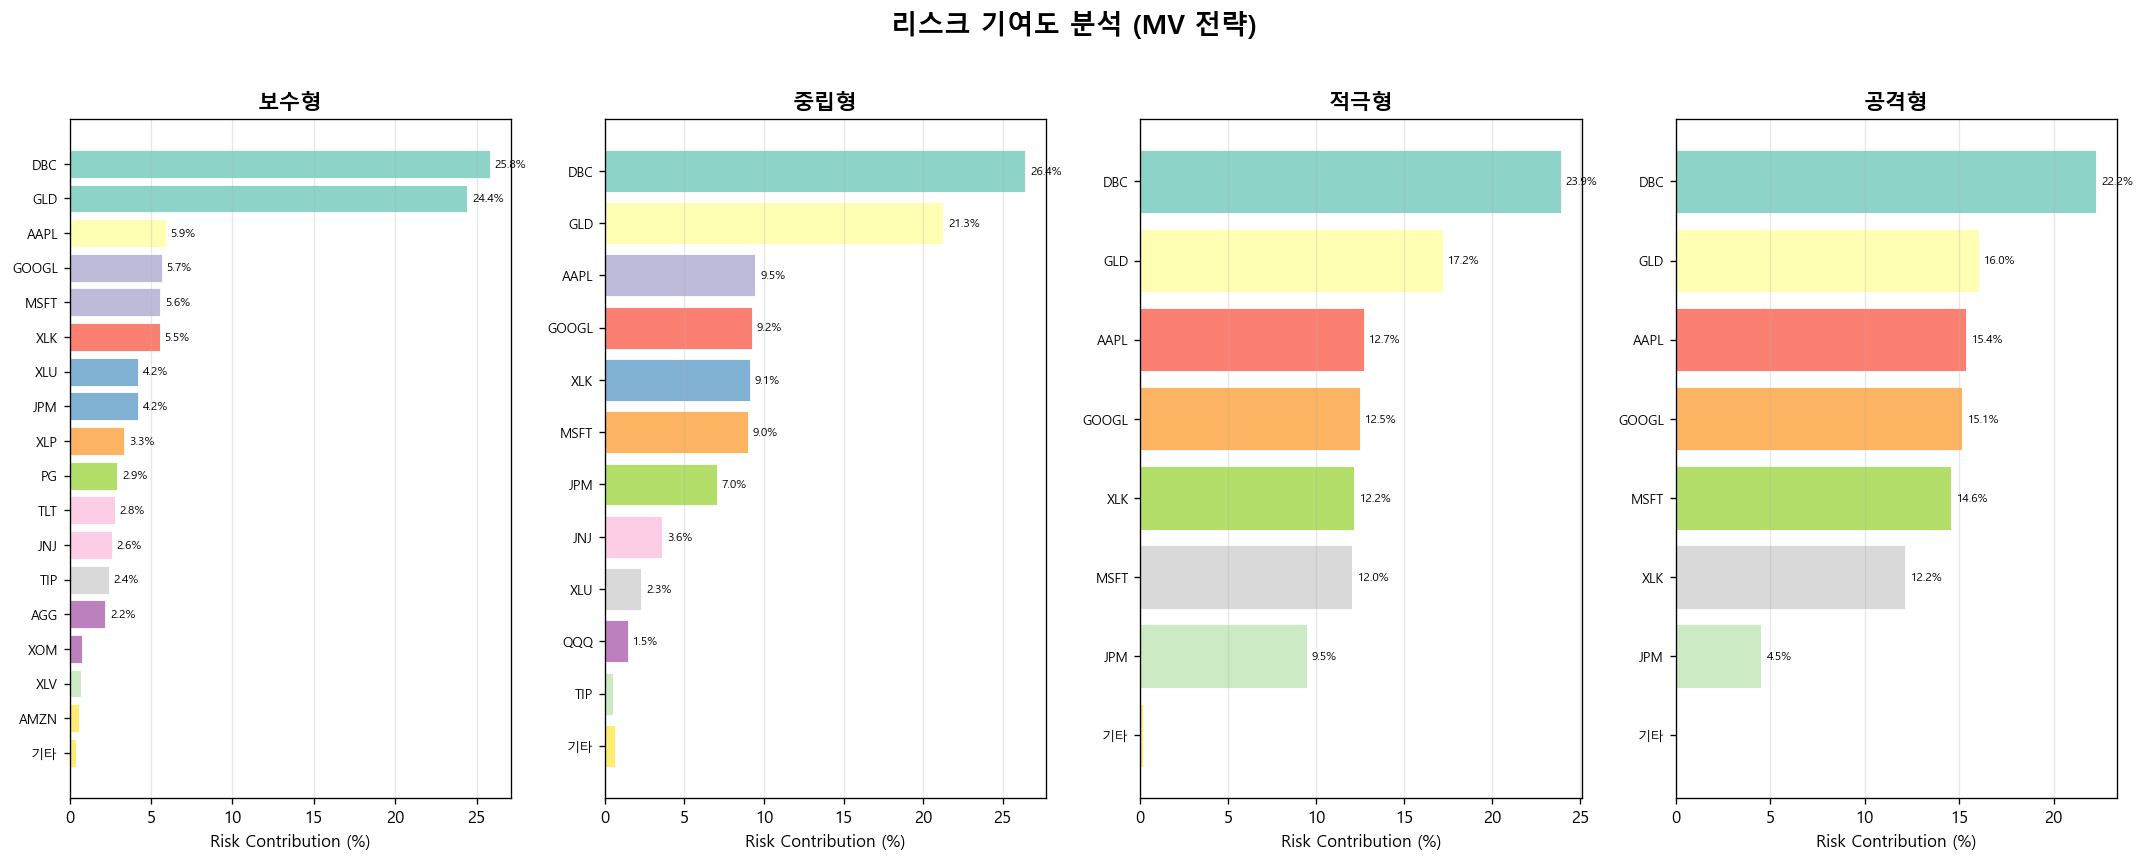

[SAVE] images/step5_02_risk_contribution.png


In [4]:
# ============================================================
# 리스크 기여도 계산 + 시각화
# ============================================================

def risk_contribution(weights, cov_matrix):
    """
    각 자산의 리스크 기여도(RC) 계산.
    RC_i = w_i * (Sigma @ w)_i / sigma_p
    반환: 리스크 기여도 비율 (합계 = 1)
    """
    w = np.array(weights)
    sigma = np.array(cov_matrix)
    port_var = w @ sigma @ w
    port_vol = np.sqrt(port_var)
    # 한계 리스크 기여도: w_i * (Sigma @ w)_i
    marginal = sigma @ w
    rc = w * marginal / port_vol
    # 비율로 변환 (합계 = 1)
    rc_pct = rc / rc.sum()
    return rc_pct


# 공분산 행렬 (252 거래일 연환산)
# ⚠️ 단일 시점 분석용 (2016~2025 sample 공분산) — full-sample이라 look-ahead 포함.
#    실무 정합성을 위해 IS 윈도우별 LedoitWolf 시계열은 아래 새 셀에서 산출 (Task 11/v4.2d).
cov_matrix = log_returns.cov() * 252
tickers = df_prices.columns.tolist()

# 프로필별 리스크 기여도 계산 (MV 전략)
rc_dict = {}
for pname in PROFILE_NAMES:
    w_sub = df_weights[(df_weights['profile'] == pname) &
                       (df_weights['strategy'] == 'MV')].set_index('ticker')['weight']
    w_aligned = w_sub.reindex(tickers).fillna(0).values
    rc_pct = risk_contribution(w_aligned, cov_matrix.values)
    rc_dict[pname] = pd.Series(rc_pct, index=tickers)

df_rc = pd.DataFrame(rc_dict)

# --- 시각화: 스택드 바 차트 ---
# 리스크 기여도가 0.5% 이상인 자산만 표시, 나머지는 '기타'로 묶음
threshold = 0.005  # 0.5%

fig, axes = plt.subplots(1, 4, figsize=(18, 7))
fig.suptitle('리스크 기여도 분석 (MV 전략)', fontsize=16, fontweight='bold', y=1.02)

for idx, pname in enumerate(PROFILE_NAMES):
    ax = axes[idx]
    rc_series = df_rc[pname].sort_values(ascending=False)

    # 주요 자산 vs 기타 분리
    major = rc_series[rc_series >= threshold]
    minor_sum = rc_series[rc_series < threshold].sum()
    if minor_sum > 0:
        plot_data = pd.concat([major, pd.Series({'기타': minor_sum})])
    else:
        plot_data = major

    # 수평 스택드 바
    colors = plt.cm.Set3(np.linspace(0, 1, len(plot_data)))
    bars = ax.barh(range(len(plot_data)), plot_data.values * 100, color=colors,
                   edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(plot_data.index, fontsize=8)
    ax.set_xlabel('Risk Contribution (%)')
    ax.set_title(f'{pname}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)

    # 값 표시
    for bar, val in zip(bars, plot_data.values):
        if val >= 0.01:  # 1% 이상만 표시
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val*100:.1f}%', va='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'step5_02_risk_contribution.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('[SAVE] images/step5_02_risk_contribution.png')

---
## 5-2b. 윈도우별 Risk Contribution (IS-LedoitWolf 시계열)

Step 4의 Walk-Forward 구조(IS=24M / OOS=3M, 31 윈도우)와 동일하게 각 IS 윈도우에서 LedoitWolf 공분산을 추정하고
프로필별 Risk Contribution(RC) 시계열을 산출. 단일 시점 sample 공분산(위 5-2 셀)과 비교.

산출물:
- `data/rc_by_window.csv` — (window_id × ticker × profile) 시계열 RC
- `images/step5_05_rc_by_window.png` — 보수형/중립형/적극형/공격형 4-패널 heatmap (시간축)


생성된 walk-forward 윈도우 수: 31
saved: data/rc_by_window.csv  shape=(3720, 5)


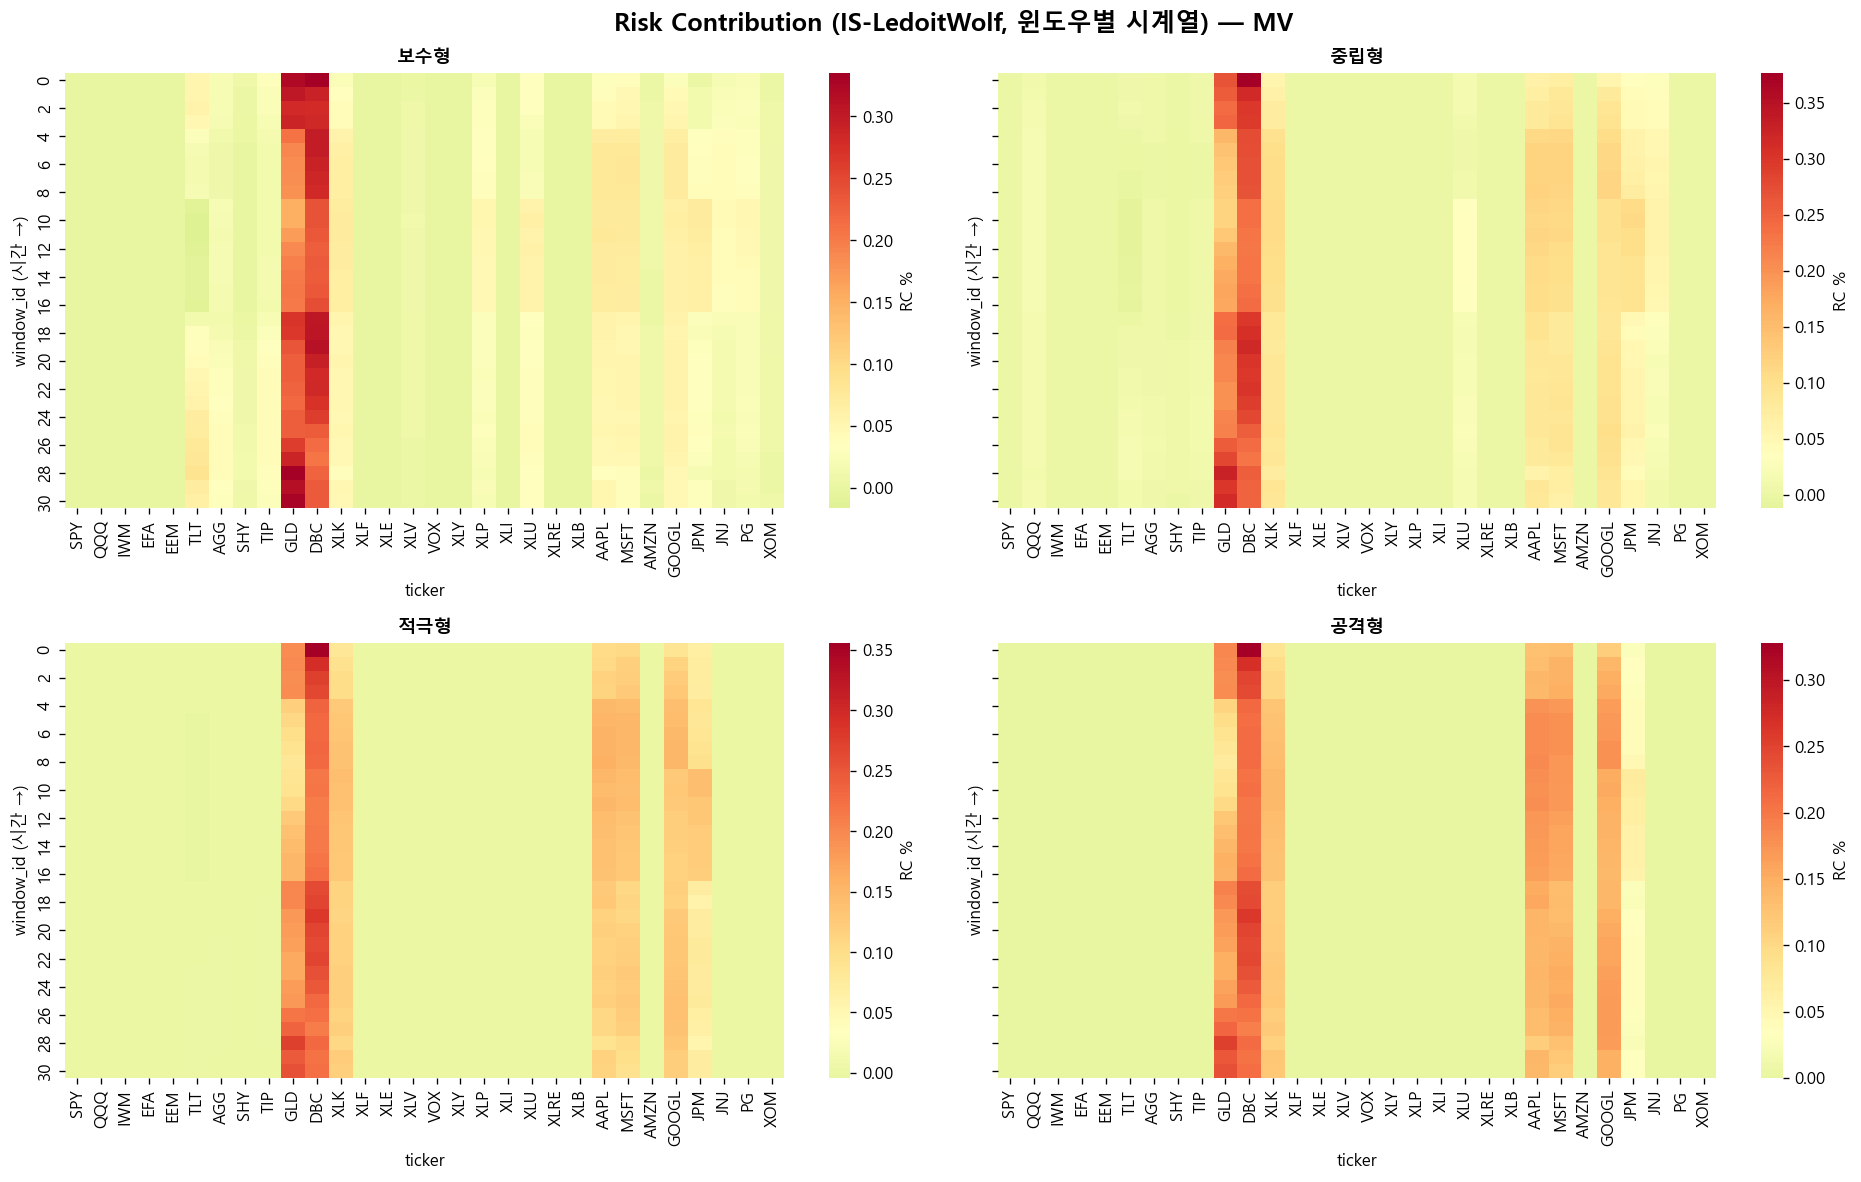

saved: images/step5_05_rc_by_window.png
[단일 시점 RC vs IS-LW 평균 RC] 차이 Top 5 (보수형):
GLD    0.010286
DBC    0.005662
TLT    0.004651
JPM    0.004120
XLU    0.003301


In [5]:
# ============================================================
# 5-2b. IS 윈도우별 LedoitWolf 기반 Risk Contribution 시계열 (Task 11/v4.2d)
# ============================================================
# Step 4와 동일한 walk-forward 구조: IS=24개월(~504일), OOS=3개월(~63일)
# 각 IS 윈도우마다 LedoitWolf 추정 → RC 계산 → 프로필별 시계열 저장
from sklearn.covariance import LedoitWolf

# 단순 수익률 (Step 4 Option Y와 일관)
simple_ret = df_prices.pct_change().dropna()
ana_ret = simple_ret.loc["2016-01-01":]

IS_DAYS  = 504   # 24M
OOS_DAYS = 63    # 3M

# Window 인덱스 생성
windows = []
i = 0
while True:
    is_start_i = i * OOS_DAYS
    is_end_i = is_start_i + IS_DAYS
    oos_end_i = is_end_i + OOS_DAYS
    if oos_end_i > len(ana_ret):
        break
    windows.append({
        "window_id": len(windows),
        "is_start": ana_ret.index[is_start_i],
        "is_end":   ana_ret.index[is_end_i - 1],
        "oos_end":  ana_ret.index[oos_end_i - 1],
    })
    i += 1
print(f"생성된 walk-forward 윈도우 수: {len(windows)}")

# 윈도우별 LW cov + RC 계산
rc_records = []
for w in windows:
    is_data = ana_ret.loc[w["is_start"]:w["is_end"]]
    if len(is_data) < 50:
        continue
    lw = LedoitWolf().fit(is_data.values)
    cov_lw = lw.covariance_ * 252
    for pname in PROFILE_NAMES:
        w_sub = df_weights[(df_weights["profile"] == pname) &
                           (df_weights["strategy"] == "MV")].set_index("ticker")["weight"]
        w_aligned = w_sub.reindex(tickers).fillna(0).values
        rc_pct = risk_contribution(w_aligned, cov_lw)
        for t, rc_v in zip(tickers, rc_pct):
            rc_records.append({
                "window_id": w["window_id"],
                "is_end": w["is_end"],
                "profile": pname,
                "ticker": t,
                "rc_pct": float(rc_v),
            })

df_rc_window = pd.DataFrame(rc_records)
df_rc_window.to_csv(os.path.join(DATA_DIR, "rc_by_window.csv"), index=False)
print(f"saved: data/rc_by_window.csv  shape={df_rc_window.shape}")

# 시각화: 4-패널 heatmap (window x ticker, profile별)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle("Risk Contribution (IS-LedoitWolf, 윈도우별 시계열) — MV", fontsize=15, fontweight="bold")
for ax, pname in zip(axes.flat, PROFILE_NAMES):
    sub = df_rc_window[df_rc_window["profile"] == pname]
    pivot = sub.pivot(index="window_id", columns="ticker", values="rc_pct").reindex(columns=tickers)
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", center=1/30,
                cbar_kws={"label": "RC %"}, linewidths=0)
    ax.set_title(f"{pname}", fontsize=11, fontweight="bold")
    ax.set_xlabel("ticker")
    ax.set_ylabel("window_id (시간 →)")
plt.tight_layout()
out_path = os.path.join(IMG_DIR, "step5_05_rc_by_window.png")
fig.savefig(out_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"saved: images/step5_05_rc_by_window.png")

# 단일 시점 vs 시계열 비교 — 보수형 기준
single_rc = df_rc["보수형"]
mean_window_rc = df_rc_window[df_rc_window["profile"] == "보수형"].groupby("ticker")["rc_pct"].mean().reindex(tickers)
diff = (single_rc - mean_window_rc).abs().sort_values(ascending=False)
print("[단일 시점 RC vs IS-LW 평균 RC] 차이 Top 5 (보수형):")
print(diff.head().to_string())


---

## 5-3. 스트레스 테스트

### 개념

포트폴리오가 **극단적 시장 상황**에서 어떻게 반응하는지 시뮬레이션합니다.

### 테스트 유형

| 유형 | 설명 | 예시 |
|:---|:---|:---|
| **역사적 시나리오** | 실제 위기 기간의 수익률 재현 | COVID-19, 2018 VIX 폭발 |
| **가상 시나리오** | 가상의 극단적 충격을 시뮬레이션 | 유가 +50%, VIX 80 |

### 해석 가이드

- 역사적 시나리오: 실제 발생한 위기 재현 → **신뢰성 높음**
- 가상 시나리오: 아직 발생하지 않은 극단적 상황 → **방어적 분석**

In [6]:
# ============================================================
# 스트레스 테스트: 11개 시나리오 정의 + 계산
# ============================================================

# --- 1) 역사적 시나리오 (6건) ---
# 실제 위기 기간의 시작일~종료일 정의
historical_scenarios = {
    '2016 중국 위기':   ('2016-01-04', '2016-02-11'),  # 중국 증시 급락 + 위안화 평가절하
    '2018 VIX 폭발':      ('2018-02-02', '2018-02-09'),  # XIV 파산, VIX 50 돌파
    '2020 COVID-19':       ('2020-02-19', '2020-03-23'),  # 팬데믹 급락
    '2022 금리 인상':    ('2022-01-03', '2022-06-16'),  # Fed 금리 인상 사이클
    '2023 SVB 파산':     ('2023-03-08', '2023-03-15'),  # 실리콘밸리 은행 파산
    '2024 엔캐리':     ('2024-08-01', '2024-08-05'),  # 엔화 캐리트레이드 청산
}

# 역사적 시나리오: 실제 포트폴리오 수익률 계산
hist_stress_results = []
for scenario, (start, end) in historical_scenarios.items():
    # 해당 기간의 일별 수익률 추출
    mask = (df_bt.index >= start) & (df_bt.index <= end)
    if mask.sum() == 0:
        # 데이터 범위 밖이면 NaN 처리
        for pname in PROFILE_NAMES:
            hist_stress_results.append({
                '시나리오': scenario, '유형': '역사적',
                '프로필': pname, '누적수익률(%)': np.nan,
                '최대낙폭(%)': np.nan, '기간(일)': 0
            })
        continue

    period_ret = df_bt.loc[mask]
    for pname in PROFILE_NAMES:
        # 누적 수익률 (단순 수익률 기반 복리, 2026-04-19 Option Y)
        # df_bt가 단순 수익률이므로 (1+r).cumprod() 로 누적 부(wealth) 계산
        cum_wealth = (1 + period_ret[pname]).cumprod()
        cum_ret = cum_wealth.iloc[-1] - 1
        # 기간 내 최대 낙폭 (퍼센트 drawdown)
        running_max = cum_wealth.cummax()
        dd = (cum_wealth / running_max) - 1
        max_dd = dd.min()

        hist_stress_results.append({
            '시나리오': scenario,
            '유형': '역사적',
            '프로필': pname,
            '누적수익률(%)': round(cum_ret * 100, 2),
            '최대낙폭(%)': round(max_dd * 100, 2),
            '기간(일)': int(mask.sum())
        })

df_hist_stress = pd.DataFrame(hist_stress_results)

# --- 2) 가상 시나리오 (5건) ---
# 각 시나리오에 대한 자산별 충격 벡터 정의
# 정규화된 충격을 포트폴리오 가중치와 곱하여 영향 추정

# 자산 그룹 정의
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX',
              'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
EQUITY_ALL = INDEX_ETF + SECTOR_ETF + STOCKS

# 가상 시나리오 충격 벡터 (30개 자산, 일별 수익률 충격)
hypothetical_scenarios = {}

# 1) 유가 +50% 충격: 에너지 관련 급등, 주식 -10%, 채권 보합, 금 상승
shock_oil = pd.Series(0.0, index=tickers)
shock_oil[['XLE', 'XOM']] = 0.15           # 에너지 상승 수혜
shock_oil[['DBC']] = 0.20                   # 원자재 ETF 상승
for t in INDEX_ETF:
    shock_oil[t] = -0.05                     # 주식 지수 하락
for t in SECTOR_ETF:
    if t not in ['XLE']:
        shock_oil[t] = -0.04
for t in STOCKS:
    if t not in ['XOM']:
        shock_oil[t] = -0.06
shock_oil[['TLT', 'AGG']] = 0.02            # 안전자산 소폭 상승
shock_oil[['GLD']] = 0.03                    # 금 상승
hypothetical_scenarios['유가 +50% 급등'] = shock_oil

# 2) VIX 80 시나리오: 주식 전반 급락, 채권 상승, 금 상승
shock_vix = pd.Series(0.0, index=tickers)
for t in EQUITY_ALL:
    shock_vix[t] = -0.12                     # 주식 대폭락
shock_vix[['TLT']] = 0.06                   # 장기채 급등 (flight to safety)
shock_vix[['AGG', 'SHY', 'TIP']] = 0.02    # 채권 소폭 상승
shock_vix[['GLD']] = 0.05                   # 금 안전자산 수요
shock_vix[['DBC']] = -0.08                  # 원자재 하락
hypothetical_scenarios['VIX 80 급등'] = shock_vix

# 3) 신용 경색 (HY 스프레드 +300bp): 금융주 급락, 채권 혼재
shock_credit = pd.Series(0.0, index=tickers)
shock_credit[['XLF', 'JPM']] = -0.15        # 금융주 급락
for t in INDEX_ETF:
    shock_credit[t] = -0.06
for t in STOCKS:
    shock_credit[t] = -0.05
for t in SECTOR_ETF:
    if t != 'XLF':
        shock_credit[t] = -0.04
shock_credit[['TLT']] = 0.04                # 장기채 상승 (금리 인하 기대)
shock_credit[['AGG']] = -0.02               # 회사채 포함으로 하락
shock_credit[['GLD']] = 0.03
hypothetical_scenarios['신용경색 HY+300bp'] = shock_credit

# 4) 스태그플레이션: 주식 하락 + 채권도 하락 + 금/원자재 상승
shock_stagflation = pd.Series(0.0, index=tickers)
for t in EQUITY_ALL:
    shock_stagflation[t] = -0.08
shock_stagflation[['TLT']] = -0.05          # 인플레로 채권도 하락
shock_stagflation[['AGG']] = -0.03
shock_stagflation[['TIP']] = 0.02           # TIPS는 인플레 헤지
shock_stagflation[['SHY']] = 0.00
shock_stagflation[['GLD']] = 0.08           # 금 급등
shock_stagflation[['DBC']] = 0.10           # 원자재 급등
hypothetical_scenarios['스태그플레이션'] = shock_stagflation

# 5) VIX 구조 붕괴: 변동성 급등 + 상관관계 복괴 (모든 자산 동반 하락)
shock_vix_collapse = pd.Series(0.0, index=tickers)
for t in EQUITY_ALL:
    shock_vix_collapse[t] = -0.10
shock_vix_collapse[['TLT', 'AGG', 'TIP']] = -0.03  # 채권도 동반 하락
shock_vix_collapse[['SHY']] = -0.01
shock_vix_collapse[['GLD']] = -0.02                 # 금도 소폭 하락
shock_vix_collapse[['DBC']] = -0.06                 # 원자재 하락
hypothetical_scenarios['VIX 구조 붕괴'] = shock_vix_collapse

# --- 가상 시나리오 충격 계산 ---
hypo_stress_results = []
for scenario, shock_vector in hypothetical_scenarios.items():
    for pname in PROFILE_NAMES:
        # MV 전략 가중치 추출
        w_sub = df_weights[(df_weights['profile'] == pname) &
                           (df_weights['strategy'] == 'MV')].set_index('ticker')['weight']
        w_aligned = w_sub.reindex(tickers).fillna(0).values
        shock_aligned = shock_vector.reindex(tickers).fillna(0).values

        # 포트폴리오 충격 = 가중평균 충격
        portfolio_shock = np.dot(w_aligned, shock_aligned)

        hypo_stress_results.append({
            '시나리오': scenario,
            '유형': '가상',
            '프로필': pname,
            '충격(%)': round(portfolio_shock * 100, 2)
        })

df_hypo_stress = pd.DataFrame(hypo_stress_results)

# --- 전체 스트레스 테스트 결과 출력 ---
print('=' * 70)
print('스트레스 테스트 결과')
print('=' * 70)

print('\n[역사적 시나리오 - 누적 수익률]')
pivot_hist = df_hist_stress.pivot_table(
    index='시나리오', columns='프로필', values='누적수익률(%)',
    aggfunc='first'
)[PROFILE_NAMES]
print(pivot_hist.to_string())

print('\n[가상 시나리오 - 포트폴리오 충격]')
pivot_hypo = df_hypo_stress.pivot_table(
    index='시나리오', columns='프로필', values='충격(%)',
    aggfunc='first'
)[PROFILE_NAMES]
print(pivot_hypo.to_string())

스트레스 테스트 결과

[역사적 시나리오 - 누적 수익률]
프로필              보수형    중립형    적극형    공격형
시나리오                                     
2018 VIX 폭발    -3.78  -4.31  -4.48  -4.29
2020 COVID-19  -7.63 -15.97 -20.70 -24.64
2022 금리 인상    -10.18 -13.50 -12.25 -14.40
2023 SVB 파산    -4.41  -6.85  -7.98  -8.54
2024 엔캐리       -4.11  -6.41  -7.46  -7.82

[가상 시나리오 - 포트폴리오 충격]
프로필             보수형   중립형   적극형   공격형
시나리오                                 
VIX 80 급등     -2.89 -4.34 -5.12 -5.59
VIX 구조 붕괴     -5.19 -5.84 -6.20 -6.43
스태그플레이션        0.82  1.51  1.79  1.79
신용경색 HY+300bp -0.52 -0.81 -0.95 -1.08
유가 +50% 급등     3.21  3.67  3.88  3.86


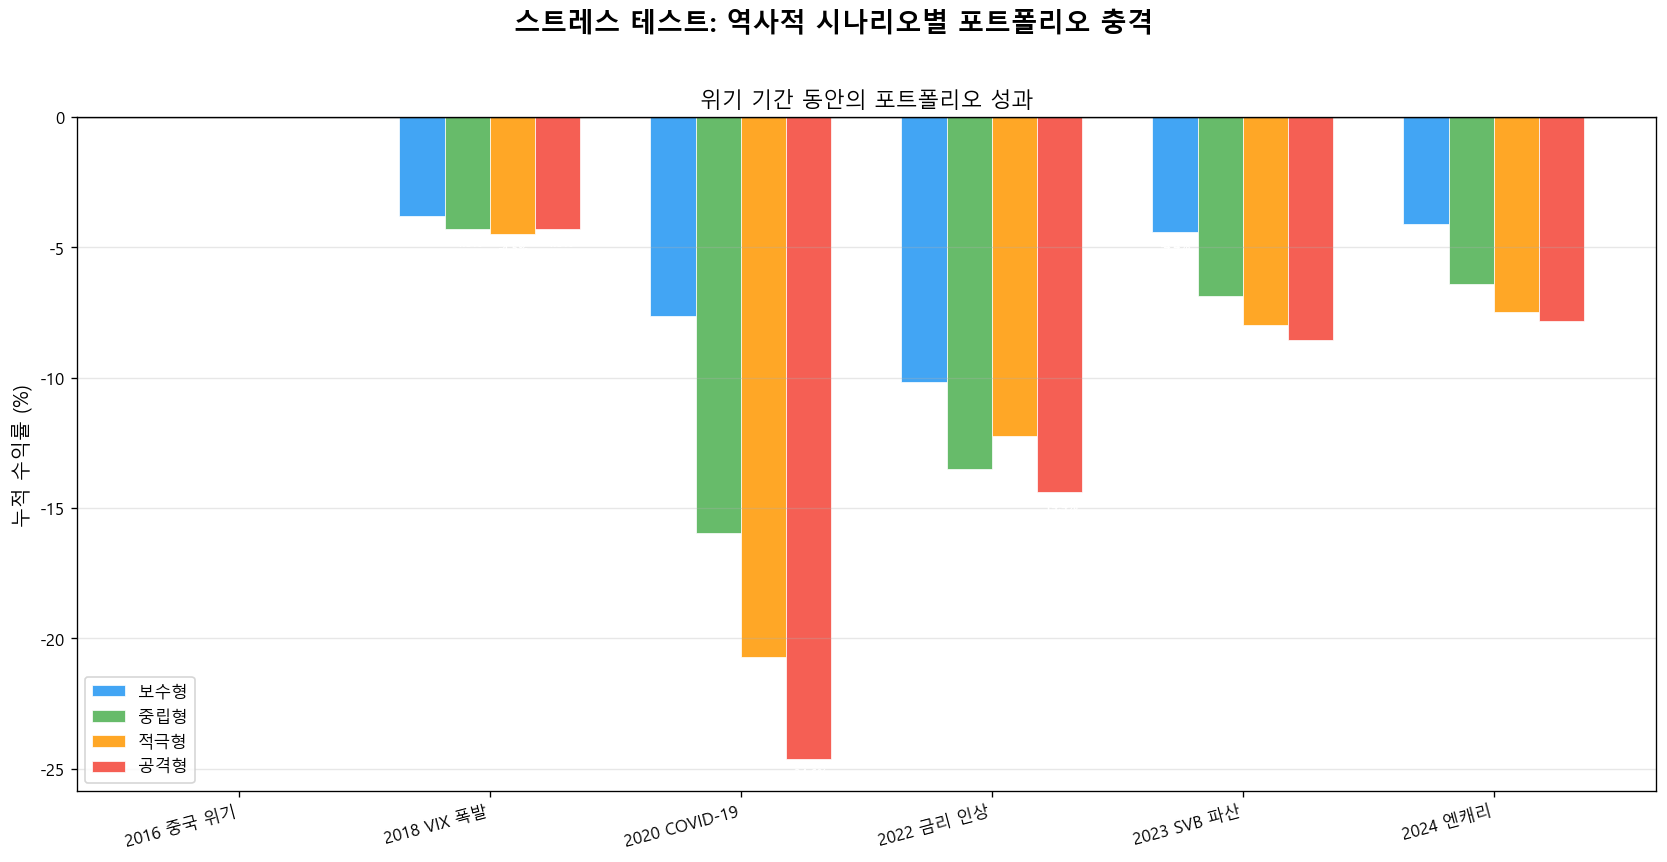

[SAVE] images/step5_03_stress_test.png


In [7]:
# ============================================================
# 시각화: 스트레스 테스트 충격 바 차트 (4 프로필 × 6 역사적 시나리오)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('스트레스 테스트: 역사적 시나리오별 포트폴리오 충격',
             fontsize=16, fontweight='bold', y=1.02)

scenarios = list(historical_scenarios.keys())
x = np.arange(len(scenarios))
width = 0.18  # 바 너비

for i, pname in enumerate(PROFILE_NAMES):
    # 역사적 시나리오 누적수익률 추출
    vals = []
    for sc in scenarios:
        row = df_hist_stress[
            (df_hist_stress['시나리오'] == sc) &
            (df_hist_stress['프로필'] == pname)
        ]
        if len(row) > 0 and not pd.isna(row['누적수익률(%)'].values[0]):
            vals.append(row['누적수익률(%)'].values[0])
        else:
            vals.append(0)

    color = PROFILE_COLORS[pname]
    bars = ax.bar(x + i * width, vals, width, label=pname,
                  color=color, edgecolor='white', linewidth=0.5, alpha=0.85)

    # 값 표시
    for bar, val in zip(bars, vals):
        if val != 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.3,
                    f'{val:.1f}%', ha='center', va='top', fontsize=7,
                    fontweight='bold', color='white')

# 시각적 요소
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(scenarios, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('누적 수익률 (%)', fontsize=12)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, axis='y', alpha=0.3)
ax.set_title('위기 기간 동안의 포트폴리오 성과', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'step5_03_stress_test.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('[SAVE] images/step5_03_stress_test.png')

---

## 5-4. 민감도 분석

### 개념

포트폴리오의 **롤링 변동성(21일)**을 계산하여 시간 경과에 따른 리스크 변화를 추적합니다.

### 해석 포인트

- 변동성 급등 구간 → 시장 스트레스 구간과 일치하는지 확인
- 프로필 간 변동성 차이 → 리스크 수준의 차별화 정도
- 보수형의 변동성이 공격형 대비 일관되게 낮아야 정상

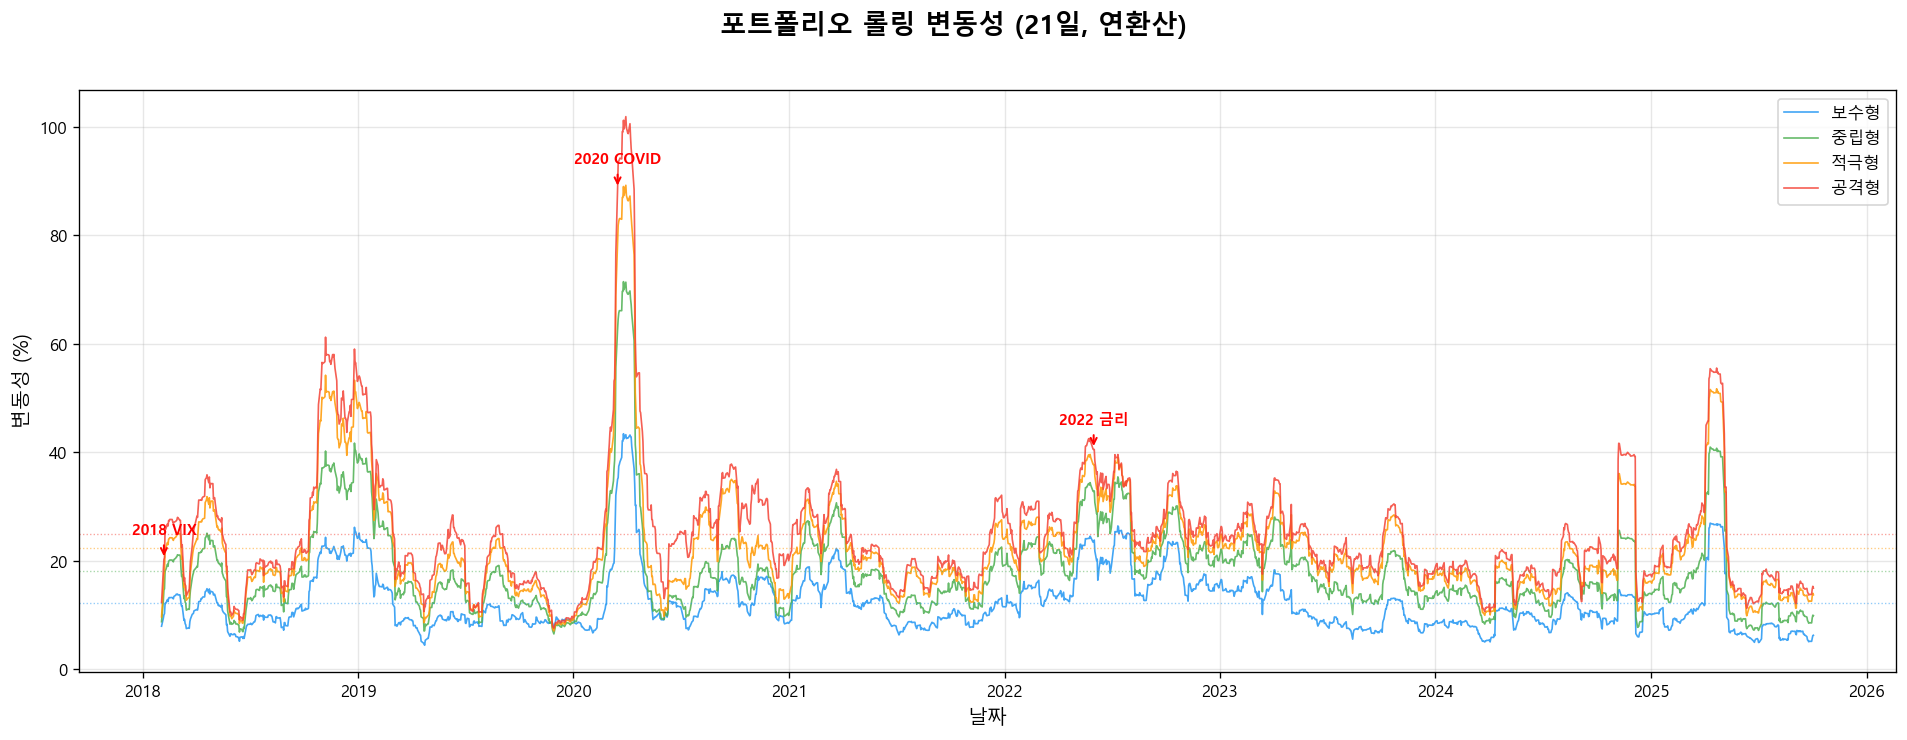

[SAVE] images/step5_04_rolling_vol.png

[롤링 변동성 통계 요약 (%, 연환산)]
              평균    중간값      최대    최소   표준편차
보수형        12.29  10.59   43.44  4.44   5.61
중립형        18.21  16.02   71.49  6.52   8.74
적극형        22.43  19.89   89.26  7.08  10.80
공격형        24.94  22.27  101.92  7.60  12.10
EW (1/30)  12.78  10.27   75.91  4.17   8.61
SPY 100%   16.56  13.71   92.97  5.01  10.92
60/40      10.37   8.63   59.09  2.84   6.83


In [8]:
# ============================================================
# 민감도 분석: 롤링 변동성 (21일) 계산 + 시각화
# ============================================================

# 21 거래일 (약 1개월) 롤링 변동성 계산
# 연환산 변환: * sqrt(252)
rolling_window = 21
df_rolling_vol = df_bt.rolling(window=rolling_window).std() * np.sqrt(252)
df_rolling_vol = df_rolling_vol.dropna()

# --- 시각화 ---
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('포트폴리오 롤링 변동성 (21일, 연환산)',
             fontsize=16, fontweight='bold', y=1.02)

for pname in PROFILE_NAMES:
    ax.plot(df_rolling_vol.index, df_rolling_vol[pname] * 100,
            label=pname, color=PROFILE_COLORS[pname], linewidth=1.0, alpha=0.85)

# 주요 위기 기간 표시
crisis_annotations = {
    '2020 COVID': '2020-03-15',
    '2018 VIX': '2018-02-06',
    '2022 금리': '2022-06-01',
}
for label, date_str in crisis_annotations.items():
    date = pd.Timestamp(date_str)
    if date in df_rolling_vol.index or (date >= df_rolling_vol.index[0] and date <= df_rolling_vol.index[-1]):
        # 가장 가까운 날짜 찾기
        nearest_idx = df_rolling_vol.index.get_indexer([date], method='nearest')[0]
        nearest_date = df_rolling_vol.index[nearest_idx]
        peak_vol = df_rolling_vol.loc[nearest_date].max() * 100
        ax.annotate(label, xy=(nearest_date, peak_vol),
                    xytext=(0, 15), textcoords='offset points',
                    fontsize=9, fontweight='bold', color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
                    ha='center')

ax.set_xlabel('날짜', fontsize=12)
ax.set_ylabel('변동성 (%)', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)

# 변동성 평균 수평선 추가
for pname in PROFILE_NAMES:
    mean_vol = df_rolling_vol[pname].mean() * 100
    ax.axhline(y=mean_vol, color=PROFILE_COLORS[pname],
               linestyle=':', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'step5_04_rolling_vol.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('[SAVE] images/step5_04_rolling_vol.png')

# 롤링 변동성 통계 요약
print('\n[롤링 변동성 통계 요약 (%, 연환산)]')
vol_stats = pd.DataFrame({
    '평균': df_rolling_vol.mean() * 100,
    '중간값': df_rolling_vol.median() * 100,
    '최대': df_rolling_vol.max() * 100,
    '최소': df_rolling_vol.min() * 100,
    '표준편차': df_rolling_vol.std() * 100,
}).round(2)
print(vol_stats.to_string())

In [9]:
# ============================================================
# 리스크 분석 결과 저장
# ============================================================

# --- VaR/CVaR 결과 ---
var_detail = []
for pname in PROFILE_NAMES:
    ret = df_bt[pname]
    for conf in confidence_levels:
        h = historical_var_cvar(ret, confidence=conf)
        p = parametric_var_cvar(ret, confidence=conf)
        var_detail.append({
            'profile': pname,
            'confidence': conf,
            'hist_VaR': round(h['VaR'], 6),
            'hist_CVaR': round(h['CVaR'], 6),
            'param_VaR': round(p['VaR'], 6),
            'param_CVaR': round(p['CVaR'], 6),
        })
df_var_detail = pd.DataFrame(var_detail)

# --- 리스크 기여도 ---
df_rc_export = df_rc.reset_index().rename(columns={'index': 'ticker'})

# --- 스트레스 테스트 결과 통합 ---
# 역사적
df_hist_export = df_hist_stress.copy()
# 가상
df_hypo_export = df_hypo_stress.copy()

# --- 롤링 변동성 통계 ---
df_vol_stats = vol_stats.reset_index().rename(columns={'index': 'profile'})

# --- 통합 저장 ---
# 여러 시트를 하나의 CSV로 저장 (리스크 분석 주요 지표)
risk_summary = []
for pname in PROFILE_NAMES:
    ret = df_bt[pname]
    h95 = historical_var_cvar(ret, 0.95)
    h99 = historical_var_cvar(ret, 0.99)
    p95 = parametric_var_cvar(ret, 0.95)
    p99 = parametric_var_cvar(ret, 0.99)
    vol_mean = df_rolling_vol[pname].mean()
    vol_max = df_rolling_vol[pname].max()

    # 역사적 스트레스 중 최악
    hist_sub = df_hist_stress[df_hist_stress['프로필'] == pname]
    worst_hist = hist_sub['누적수익률(%)'].min() if len(hist_sub) > 0 else np.nan

    risk_summary.append({
        'profile': pname,
        'hist_VaR_95': round(h95['VaR'] * 100, 3),
        'hist_CVaR_95': round(h95['CVaR'] * 100, 3),
        'hist_VaR_99': round(h99['VaR'] * 100, 3),
        'hist_CVaR_99': round(h99['CVaR'] * 100, 3),
        'param_VaR_95': round(p95['VaR'] * 100, 3),
        'param_CVaR_95': round(p95['CVaR'] * 100, 3),
        'param_VaR_99': round(p99['VaR'] * 100, 3),
        'param_CVaR_99': round(p99['CVaR'] * 100, 3),
        'rolling_vol_mean': round(vol_mean * 100, 3),
        'rolling_vol_max': round(vol_max * 100, 3),
        'worst_hist_stress': worst_hist,
    })

df_risk_summary = pd.DataFrame(risk_summary)
save_path = os.path.join(DATA_DIR, 'risk_analysis.csv')
df_risk_summary.to_csv(save_path, index=False, encoding='utf-8-sig')

print('=' * 70)
print('Step 5. 리스크 분석 완료')
print('=' * 70)
print(f'\n[저장된 파일]')
print(f'  - data/risk_analysis.csv')
print(f'  - images/step5_01_var_cvar.png')
print(f'  - images/step5_02_risk_contribution.png')
print(f'  - images/step5_03_stress_test.png')
print(f'  - images/step5_04_rolling_vol.png')
print(f'\n[리스크 분석 요약]')
print(df_risk_summary.to_string(index=False))

Step 5. 리스크 분석 완료

[저장된 파일]
  - data/risk_analysis.csv
  - images/step5_01_var_cvar.png
  - images/step5_02_risk_contribution.png
  - images/step5_03_stress_test.png
  - images/step5_04_rolling_vol.png

[리스크 분석 요약]
profile  hist_VaR_95  hist_CVaR_95  hist_VaR_99  hist_CVaR_99  param_VaR_95  param_CVaR_95  param_VaR_99  param_CVaR_99  rolling_vol_mean  rolling_vol_max  worst_hist_stress
    보수형        1.320         2.014        2.382         3.125         1.342          1.694         1.916          2.202            12.291           43.444             -10.18
    중립형        2.041         2.963        3.553         4.569         2.007          2.533         2.864          3.290            18.210           71.490             -15.97
    적극형        2.489         3.606        4.299         5.638         2.466          3.113         3.521          4.046            22.426           89.262             -20.70
    공격형        2.715         3.988        4.527         6.215         2.742          3.46